In [12]:
import qiskit
import qiskit_algorithms
import qiskit_optimization

from qiskit_aer import AerSimulator
from qiskit.primitives import Sampler
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["figure.dpi"] = 1000
mpl.rcParams["savefig.dpi"] = 1000

import math
import contextlib
import io
import os

import sys
import os
from pathlib import Path
# Add project root to path (works in Jupyter where __file__ is undefined)
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'max_k_cut').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from max_k_cut import (
    docplex_BQO, docplex_RBQO, docplex_QUBO, docplex_RQUBO,
    tight_qubo_penalty, tight_rqubo_penalty, naive_qubo_penalty, naive_rqubo_penalty,
    interpolated_qubo_penalty, interpolated_rqubo_penalty,
    generate_graph, plot_graph, feasibility_filter, expected_value
)
from max_k_cut.qaoa import run_qaoa_extract_samples
from max_k_cut.helpers import sample_std
from scripts.plot_histogram import plot_qaoa_histogram

# from qiskit_algorithms.utils import algorithm_globals
# algorithm_globals.random_seed = 123

import warnings
# Suppress specific DeprecationWarning
warnings.filterwarnings('ignore', category=DeprecationWarning)


print("qiskit version:",qiskit.__version__)
print("qiskit algorithms version:",qiskit_algorithms.__version__)
print("qiskit optimization version:",qiskit_optimization.__version__)

qiskit version: 1.3.2
qiskit algorithms version: 0.3.1
qiskit optimization version: 0.6.1


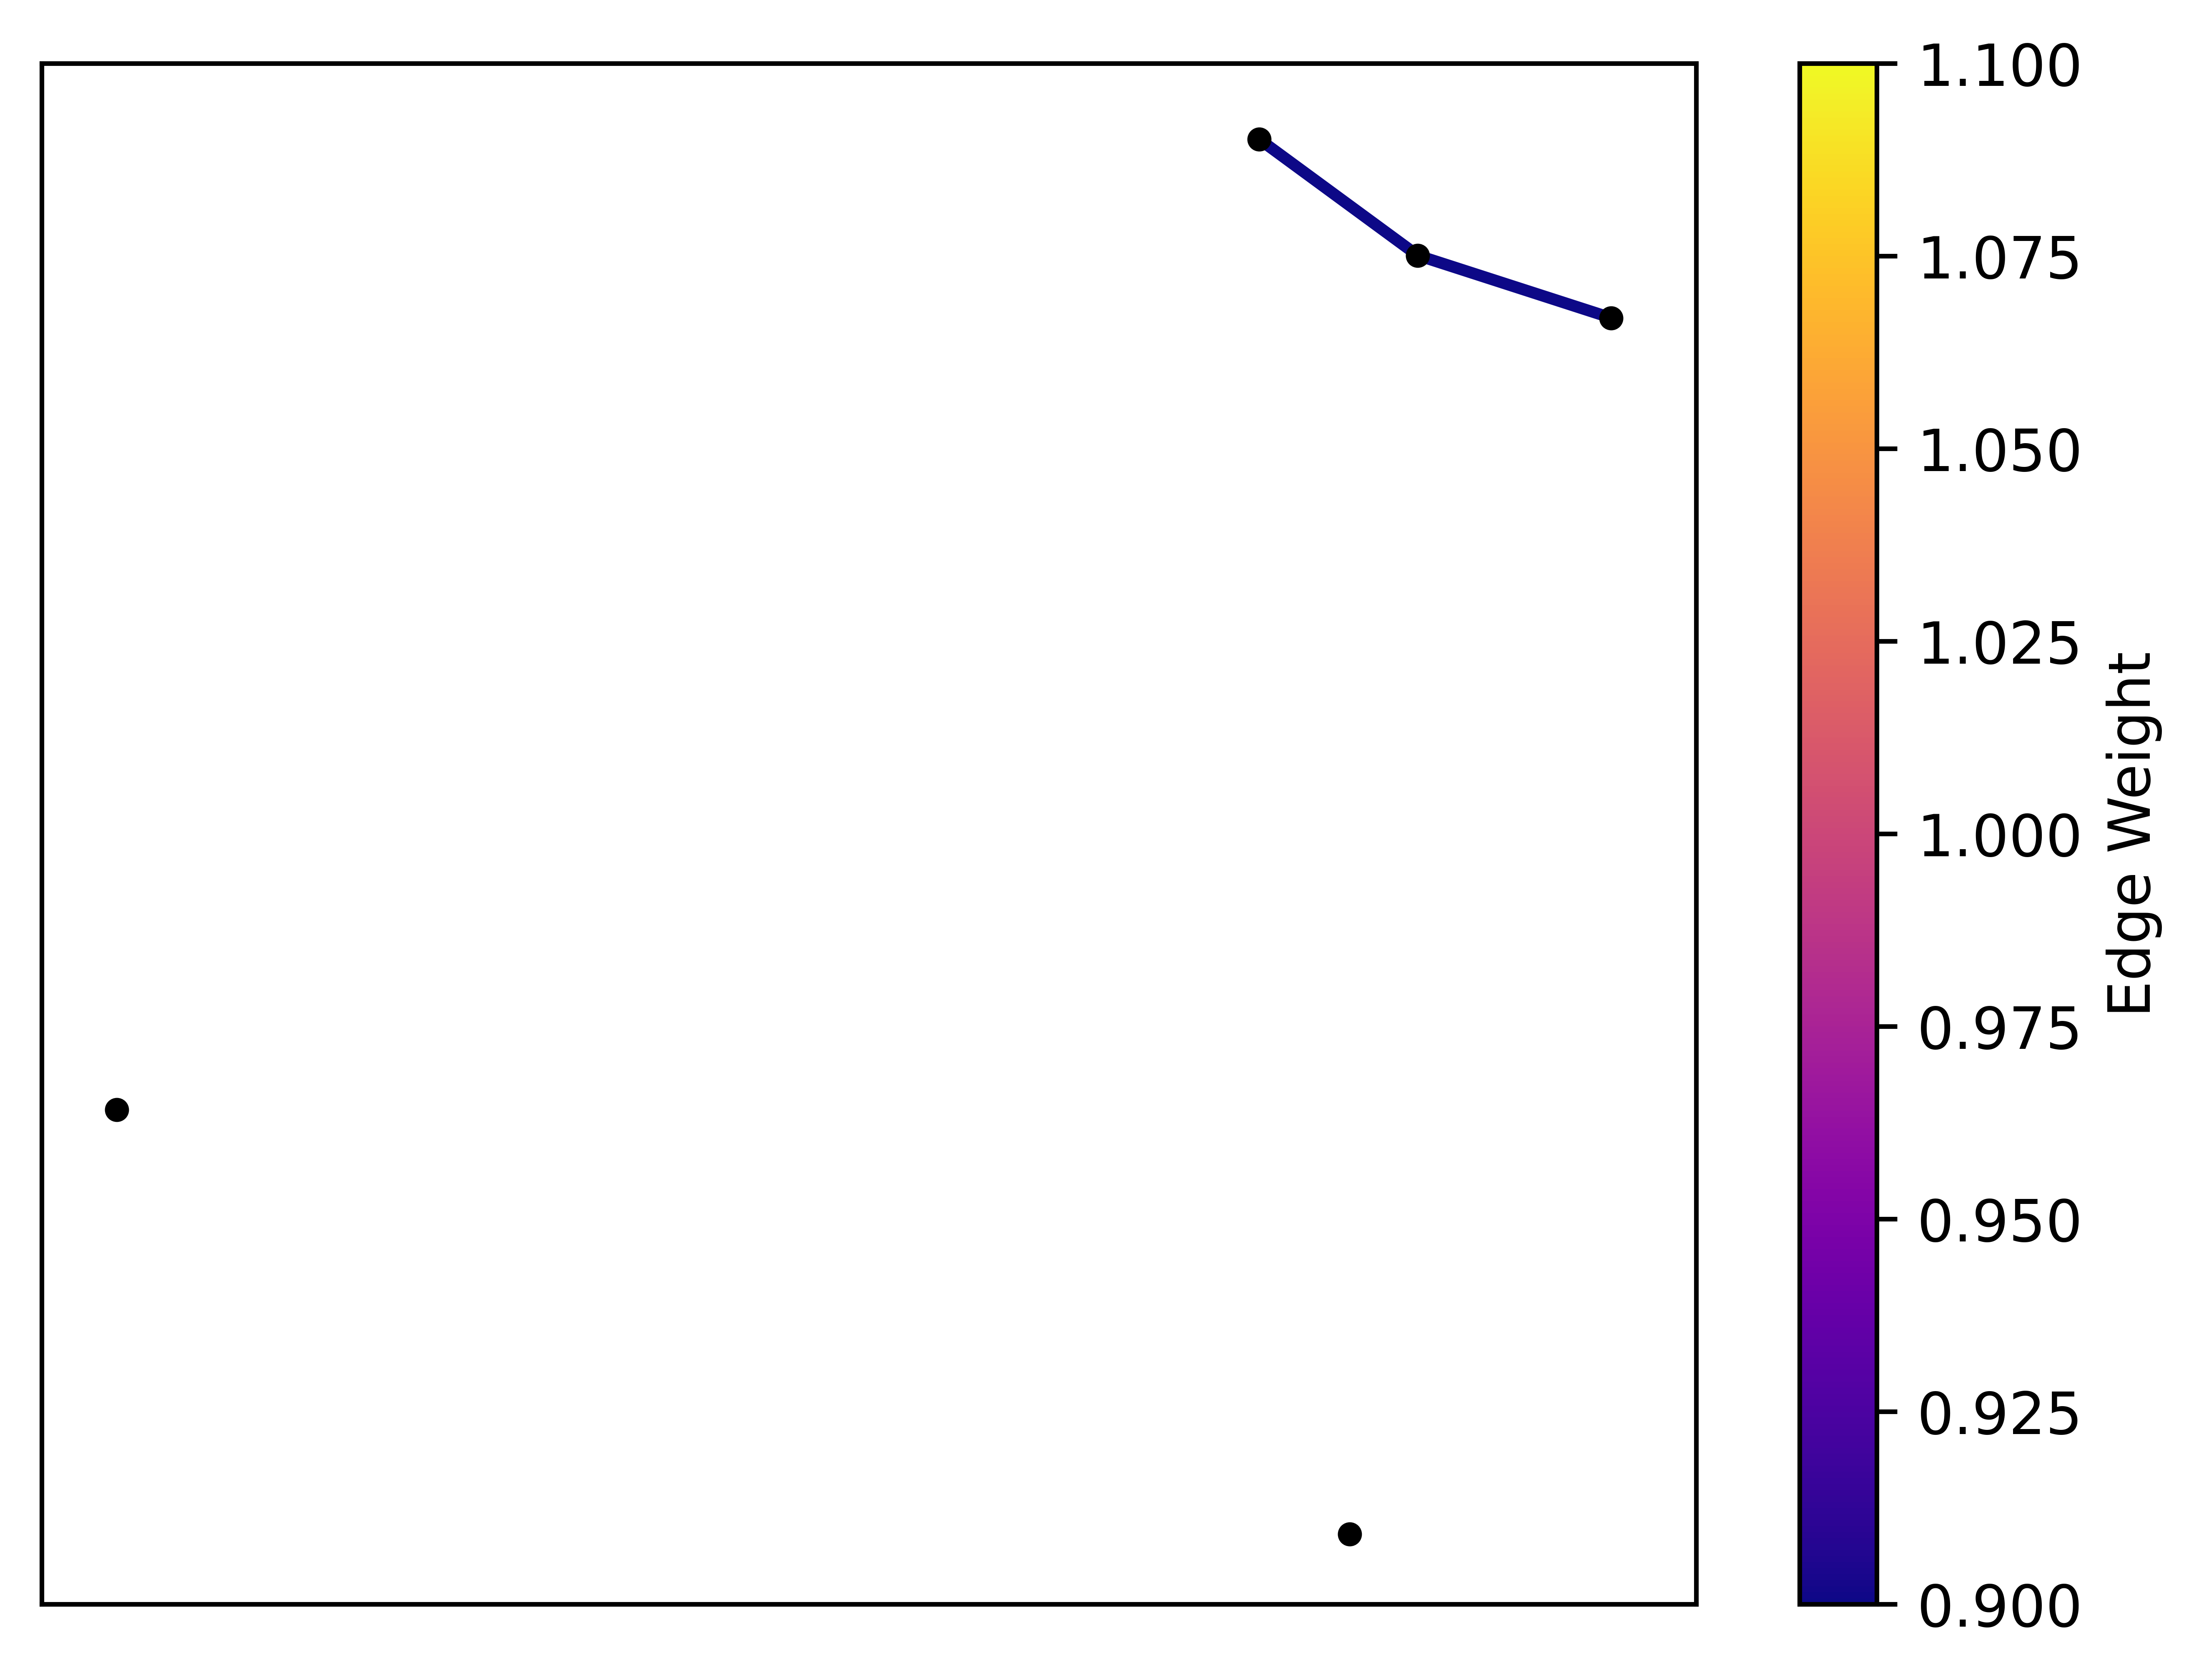

In [4]:
# Problem instance
K = 3

num_nodes = 5
edge_probability = 0.5
weighted = False
weight_range = 1

seed=1
np.random.seed(seed)

G = generate_graph(num_nodes, edge_probability, weighted, weight_range)
plot_graph(G)

In [5]:
# BQO ========================================================
dp_bqo = docplex_BQO(G, K, "Max-K-Cut")

# R-BQO ========================================================
dp_rbqo = docplex_RBQO(G, K, "Max-K-Cut")

# QUBO ========================================================
tight_penalty = tight_qubo_penalty(G, K)
dp_qubo_tight = docplex_QUBO(G, K, tight_penalty,"Max-K-Cut")

naive_penalty = naive_qubo_penalty(G, K)
dp_qubo_naive = docplex_QUBO(G, K, naive_penalty,"Max-K-Cut")

# R-QUBO ========================================================
tight_penalty = tight_rqubo_penalty(G, K)
dp_rqubo_tight = docplex_RQUBO(G, K, tight_penalty, "Max-K-Cut")

naive_penalty = naive_rqubo_penalty(G, K)
dp_rqubo_naive = docplex_RQUBO(G, K, naive_penalty, "Max-K-Cut")

In [6]:
# Solve models and get objective values
objective_values = {
    "BQO": dp_bqo.solve().objective_value,
    "RBQO": dp_rbqo.solve().objective_value,
    "QUBO (Tight)": dp_qubo_tight.solve().objective_value,
    "QUBO (Naive)": dp_qubo_naive.solve().objective_value,
    "RQUBO (Tight)": dp_rqubo_tight.solve().objective_value,
    "RQUBO (Naive)": dp_rqubo_naive.solve().objective_value
}

# Define a tolerance for the comparison
tolerance = 1e-9

# Assert that the objective values are close to each other
bqo_value = objective_values["BQO"]
for label, value in objective_values.items():
    assert math.isclose(bqo_value, value, abs_tol=tolerance), f"{label} value differs"

print(f"All objective values are close to {bqo_value} within the specified tolerance.")

MAX_FVAL = bqo_value

All objective values are close to 2.0 within the specified tolerance.


In [7]:
# parameters
backend = AerSimulator()
sampler = Sampler()
cvar_alpha = 1 # alpha for CVaR aggregation in (0,1], 1 for full distribution, 0 for only the best solution
shots = 1024/cvar_alpha
sampler.set_options(shots=shots, backend=backend)
optimizer = COBYLA()
reps = 1
initial_point = np.zeros(2 * reps)

# solvers
qaoa = QAOA(
    sampler=sampler, 
    optimizer=optimizer, 
    reps=reps, 
    initial_point=initial_point,
    aggregation=cvar_alpha
    )

np_solver = NumPyMinimumEigensolver() # exact classical solver
# create minimum eigen optimizer based on solver used
qaoa_optimizer = MinimumEigenOptimizer(qaoa)
np_optimizer = MinimumEigenOptimizer(np_solver)

# Plot all samples

In [8]:
# Run QAOA to extract raw samples for all models.
results_dict = run_qaoa_extract_samples(
    [dp_bqo, dp_rbqo, dp_qubo_tight, dp_qubo_naive, dp_rqubo_tight, dp_rqubo_naive],
    ["BQO", "RBQO", "QUBO (Tight)", "QUBO (Naive)", "RQUBO (Tight)", "RQUBO (Naive)"],
    optimizer=qaoa_optimizer
)

Solving BQO:
Classically calculating max objective value...
Max objective value for BQO: 2.0
Running QAOA...
QAOA result: objective function value: 2.0
variable values: x00=1.0, x01=0.0, x02=0.0, x10=0.0, x11=1.0, x12=0.0, x20=0.0, x21=1.0, x22=0.0, x30=1.0, x31=0.0, x32=0.0, x40=0.0, x41=0.0, x42=1.0
status: SUCCESS
Time taken: 14.8388 seconds
Solving RBQO:
Classically calculating max objective value...
Max objective value for RBQO: 2.0
Running QAOA...
QAOA result: objective function value: 2.0
variable values: x00=0.0, x01=0.0, x10=0.0, x11=0.0, x20=1.0, x21=0.0, x30=1.0, x31=0.0, x40=0.0, x41=0.0
status: SUCCESS
Time taken: 0.7821 seconds
Solving QUBO (Tight):
Classically calculating max objective value...
Max objective value for QUBO (Tight): 2.0
Running QAOA...
QAOA result: objective function value: 1.9999999999999998
variable values: x00=0.0, x01=1.0, x02=1.0, x10=0.0, x11=0.0, x12=0.0, x20=0.0, x21=1.0, x22=0.0, x30=0.0, x31=1.0, x32=0.0, x40=1.0, x41=0.0, x42=0.0
status: SUCCES

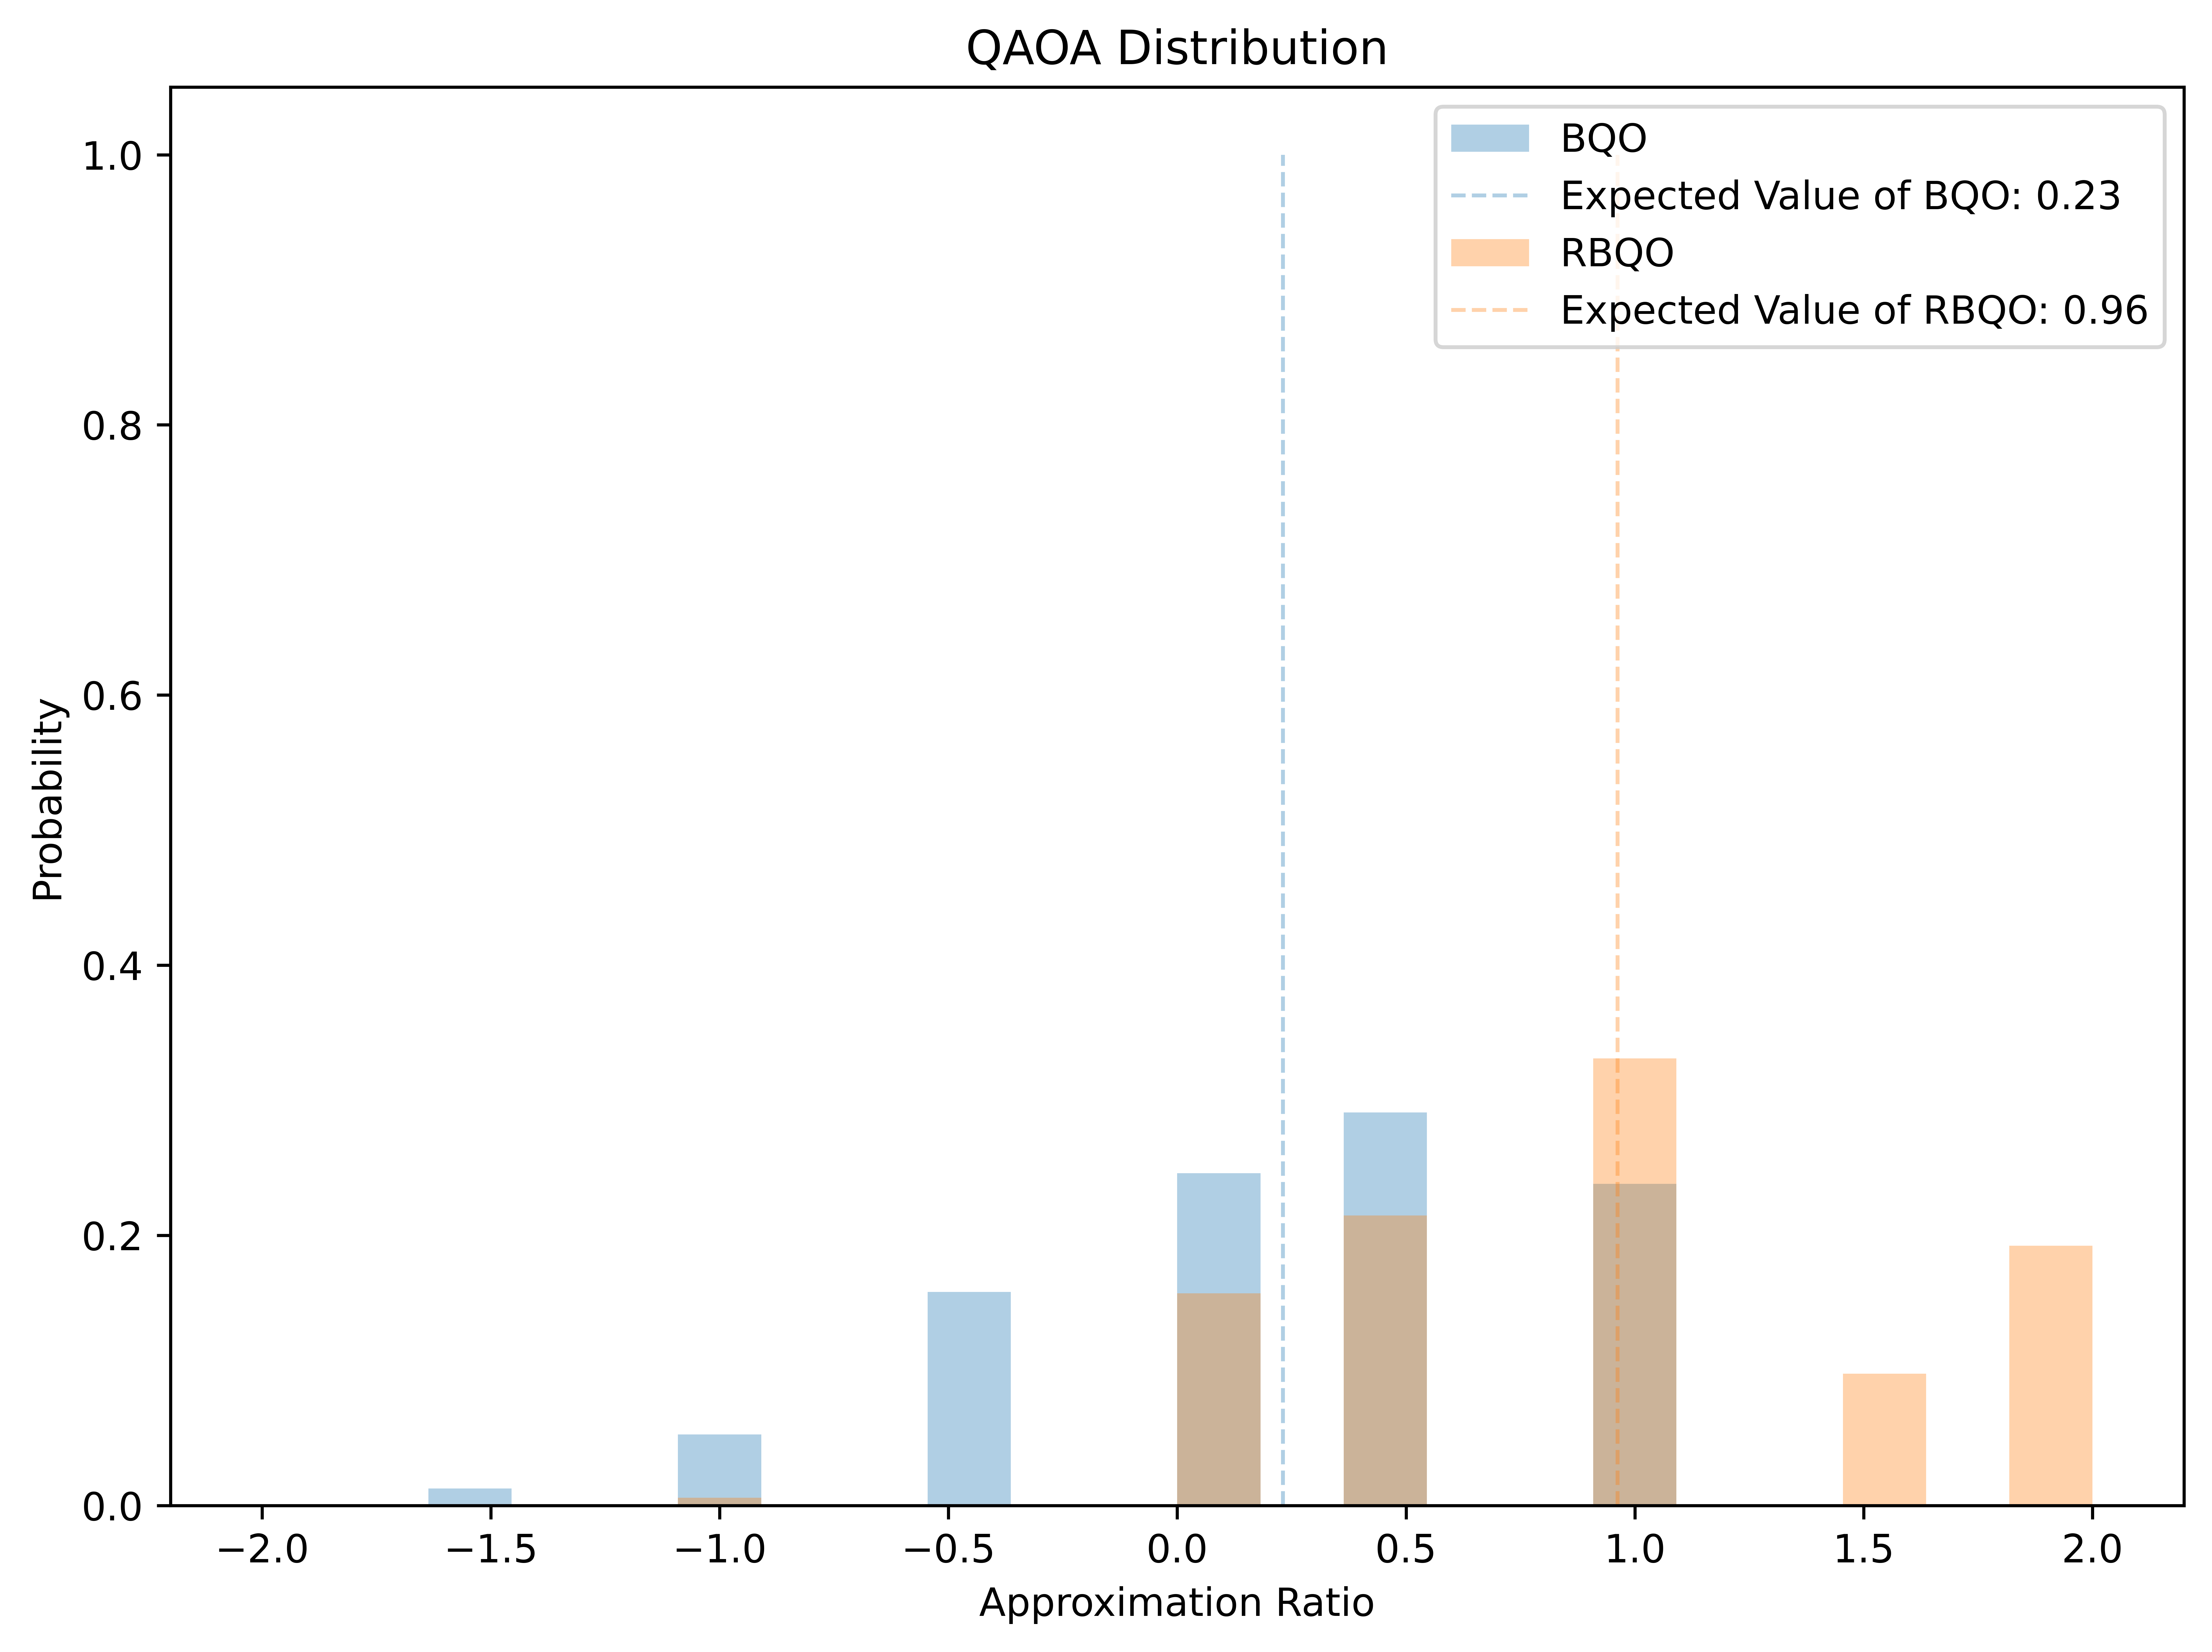

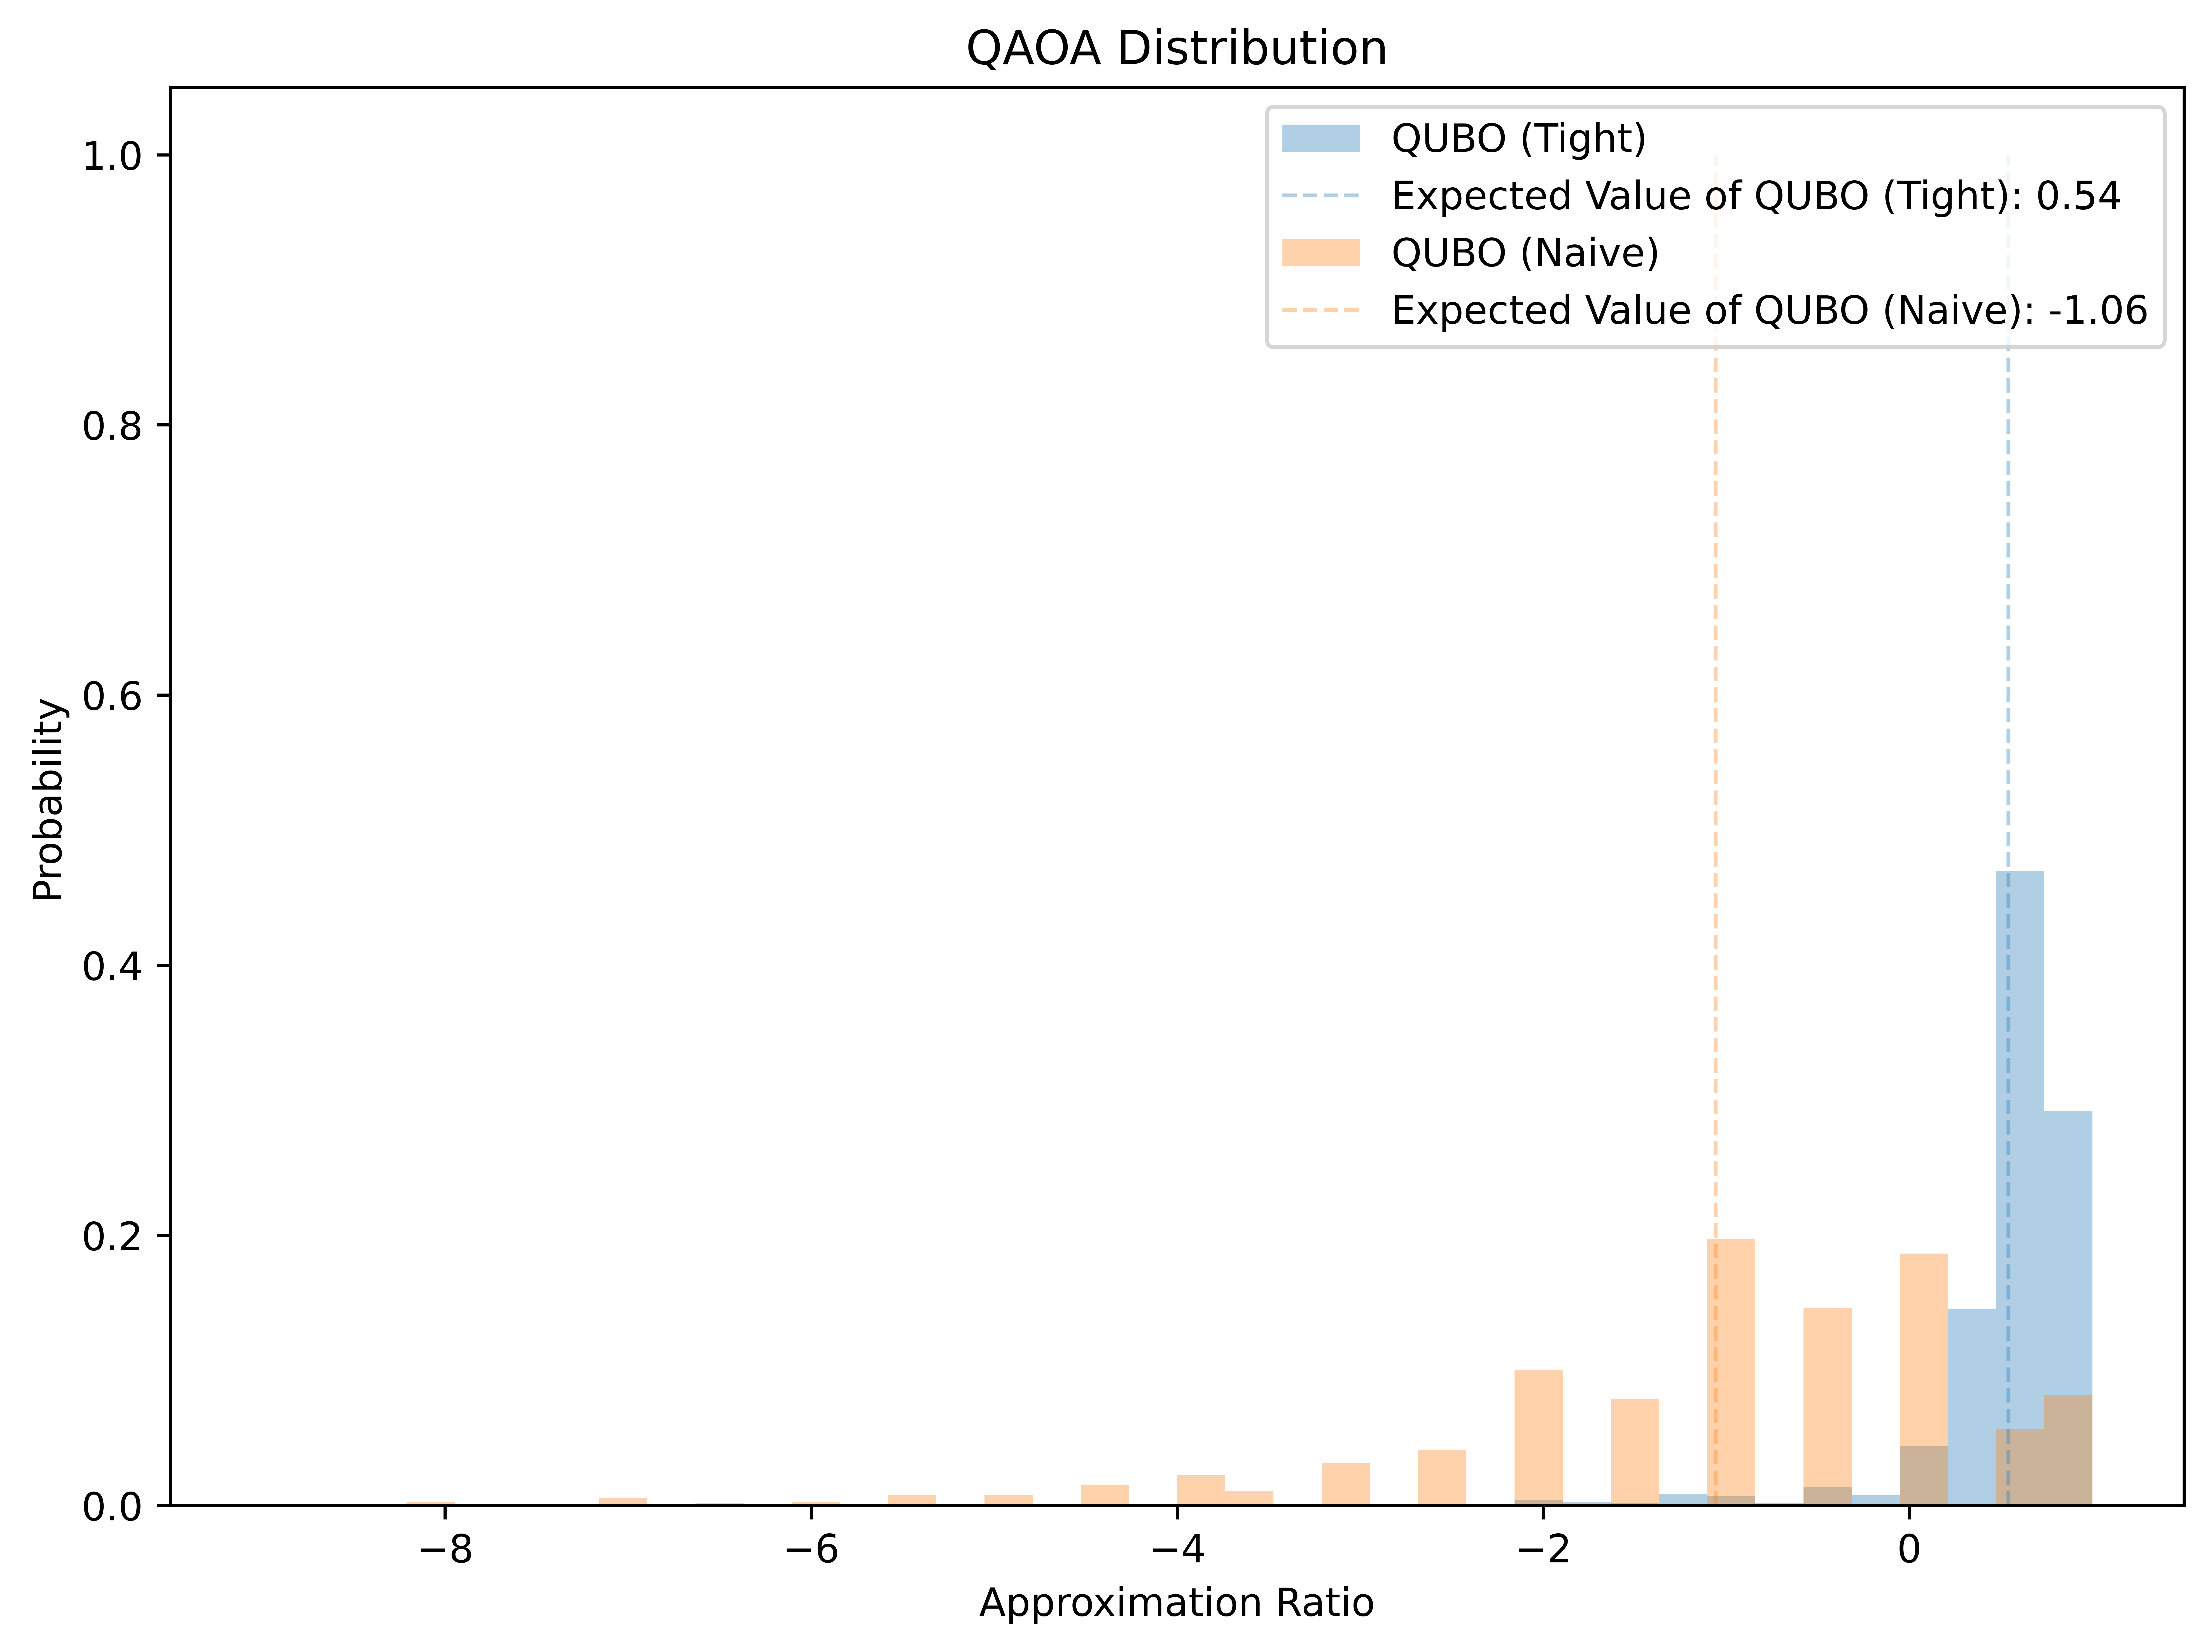

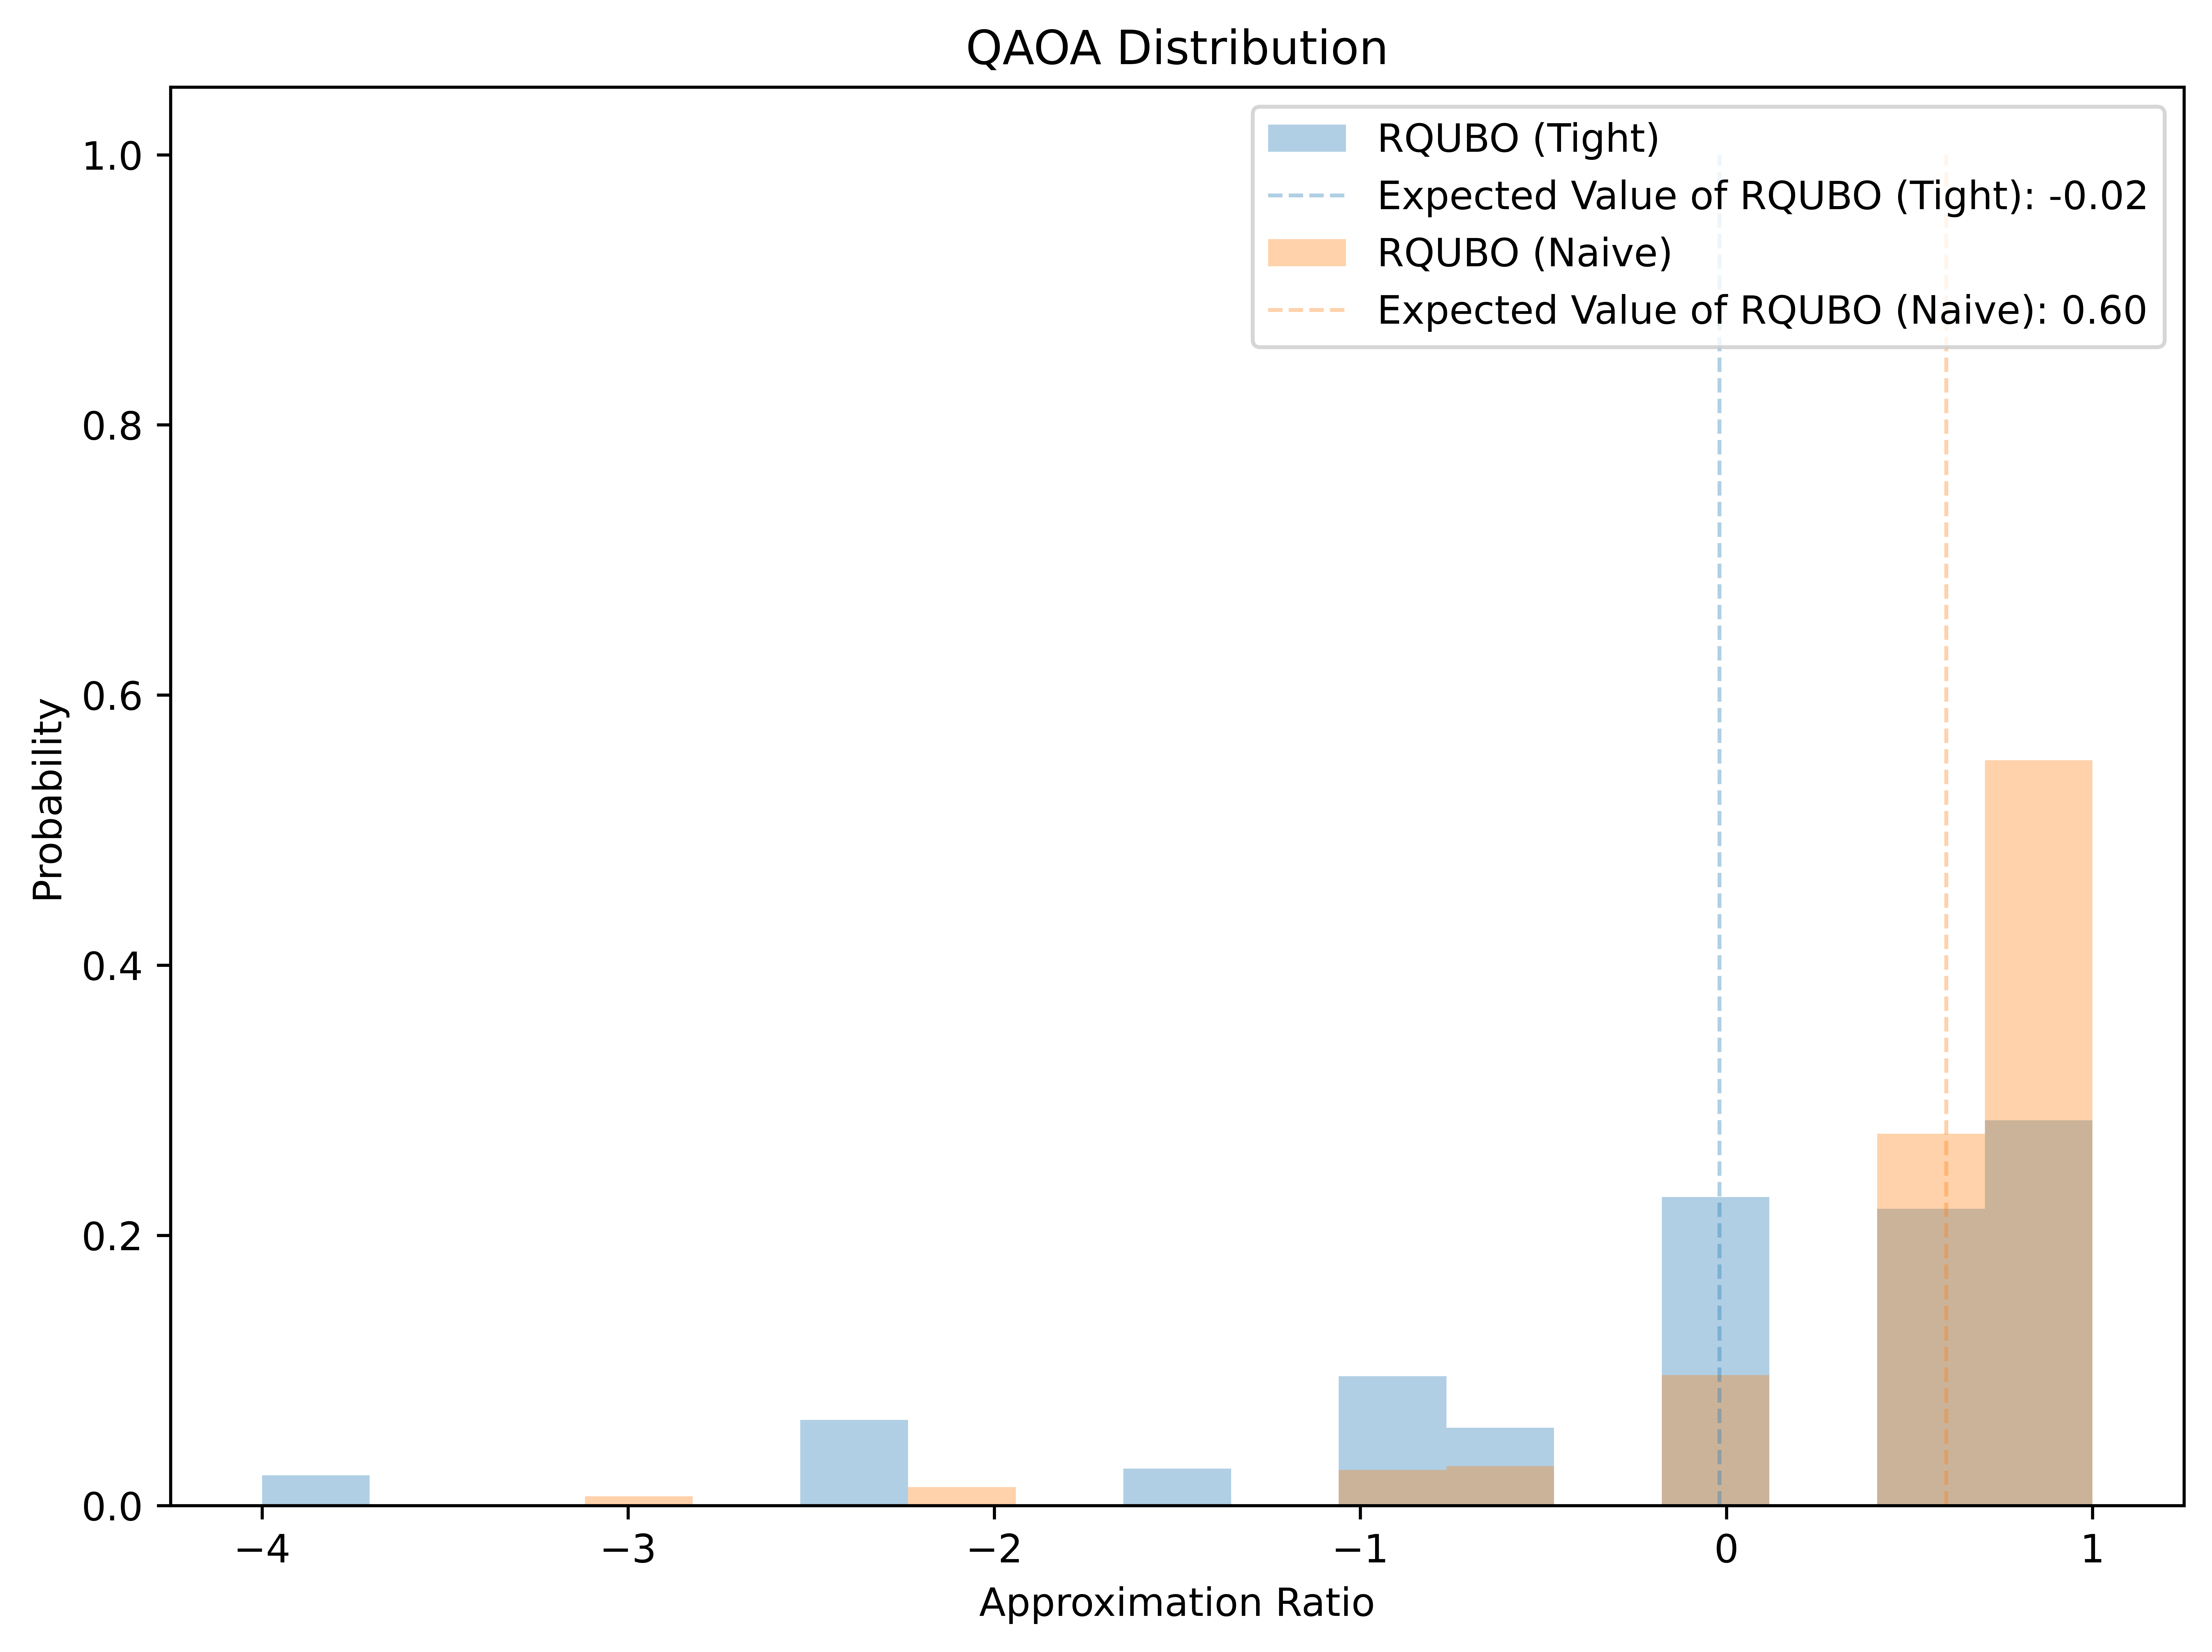

In [9]:
# Plot the histogram with default settings (no filtering, no re-penalization).
plot_qaoa_histogram(results_dict, 'BQO', 'RBQO')
plot_qaoa_histogram(results_dict, 'QUBO (Tight)', 'QUBO (Naive)')
plot_qaoa_histogram(results_dict, 'RQUBO (Tight)', 'RQUBO (Naive)')

Probability of feasible solution for BQO: 0.0039
Probability of feasible solution for RBQO: 0.2529


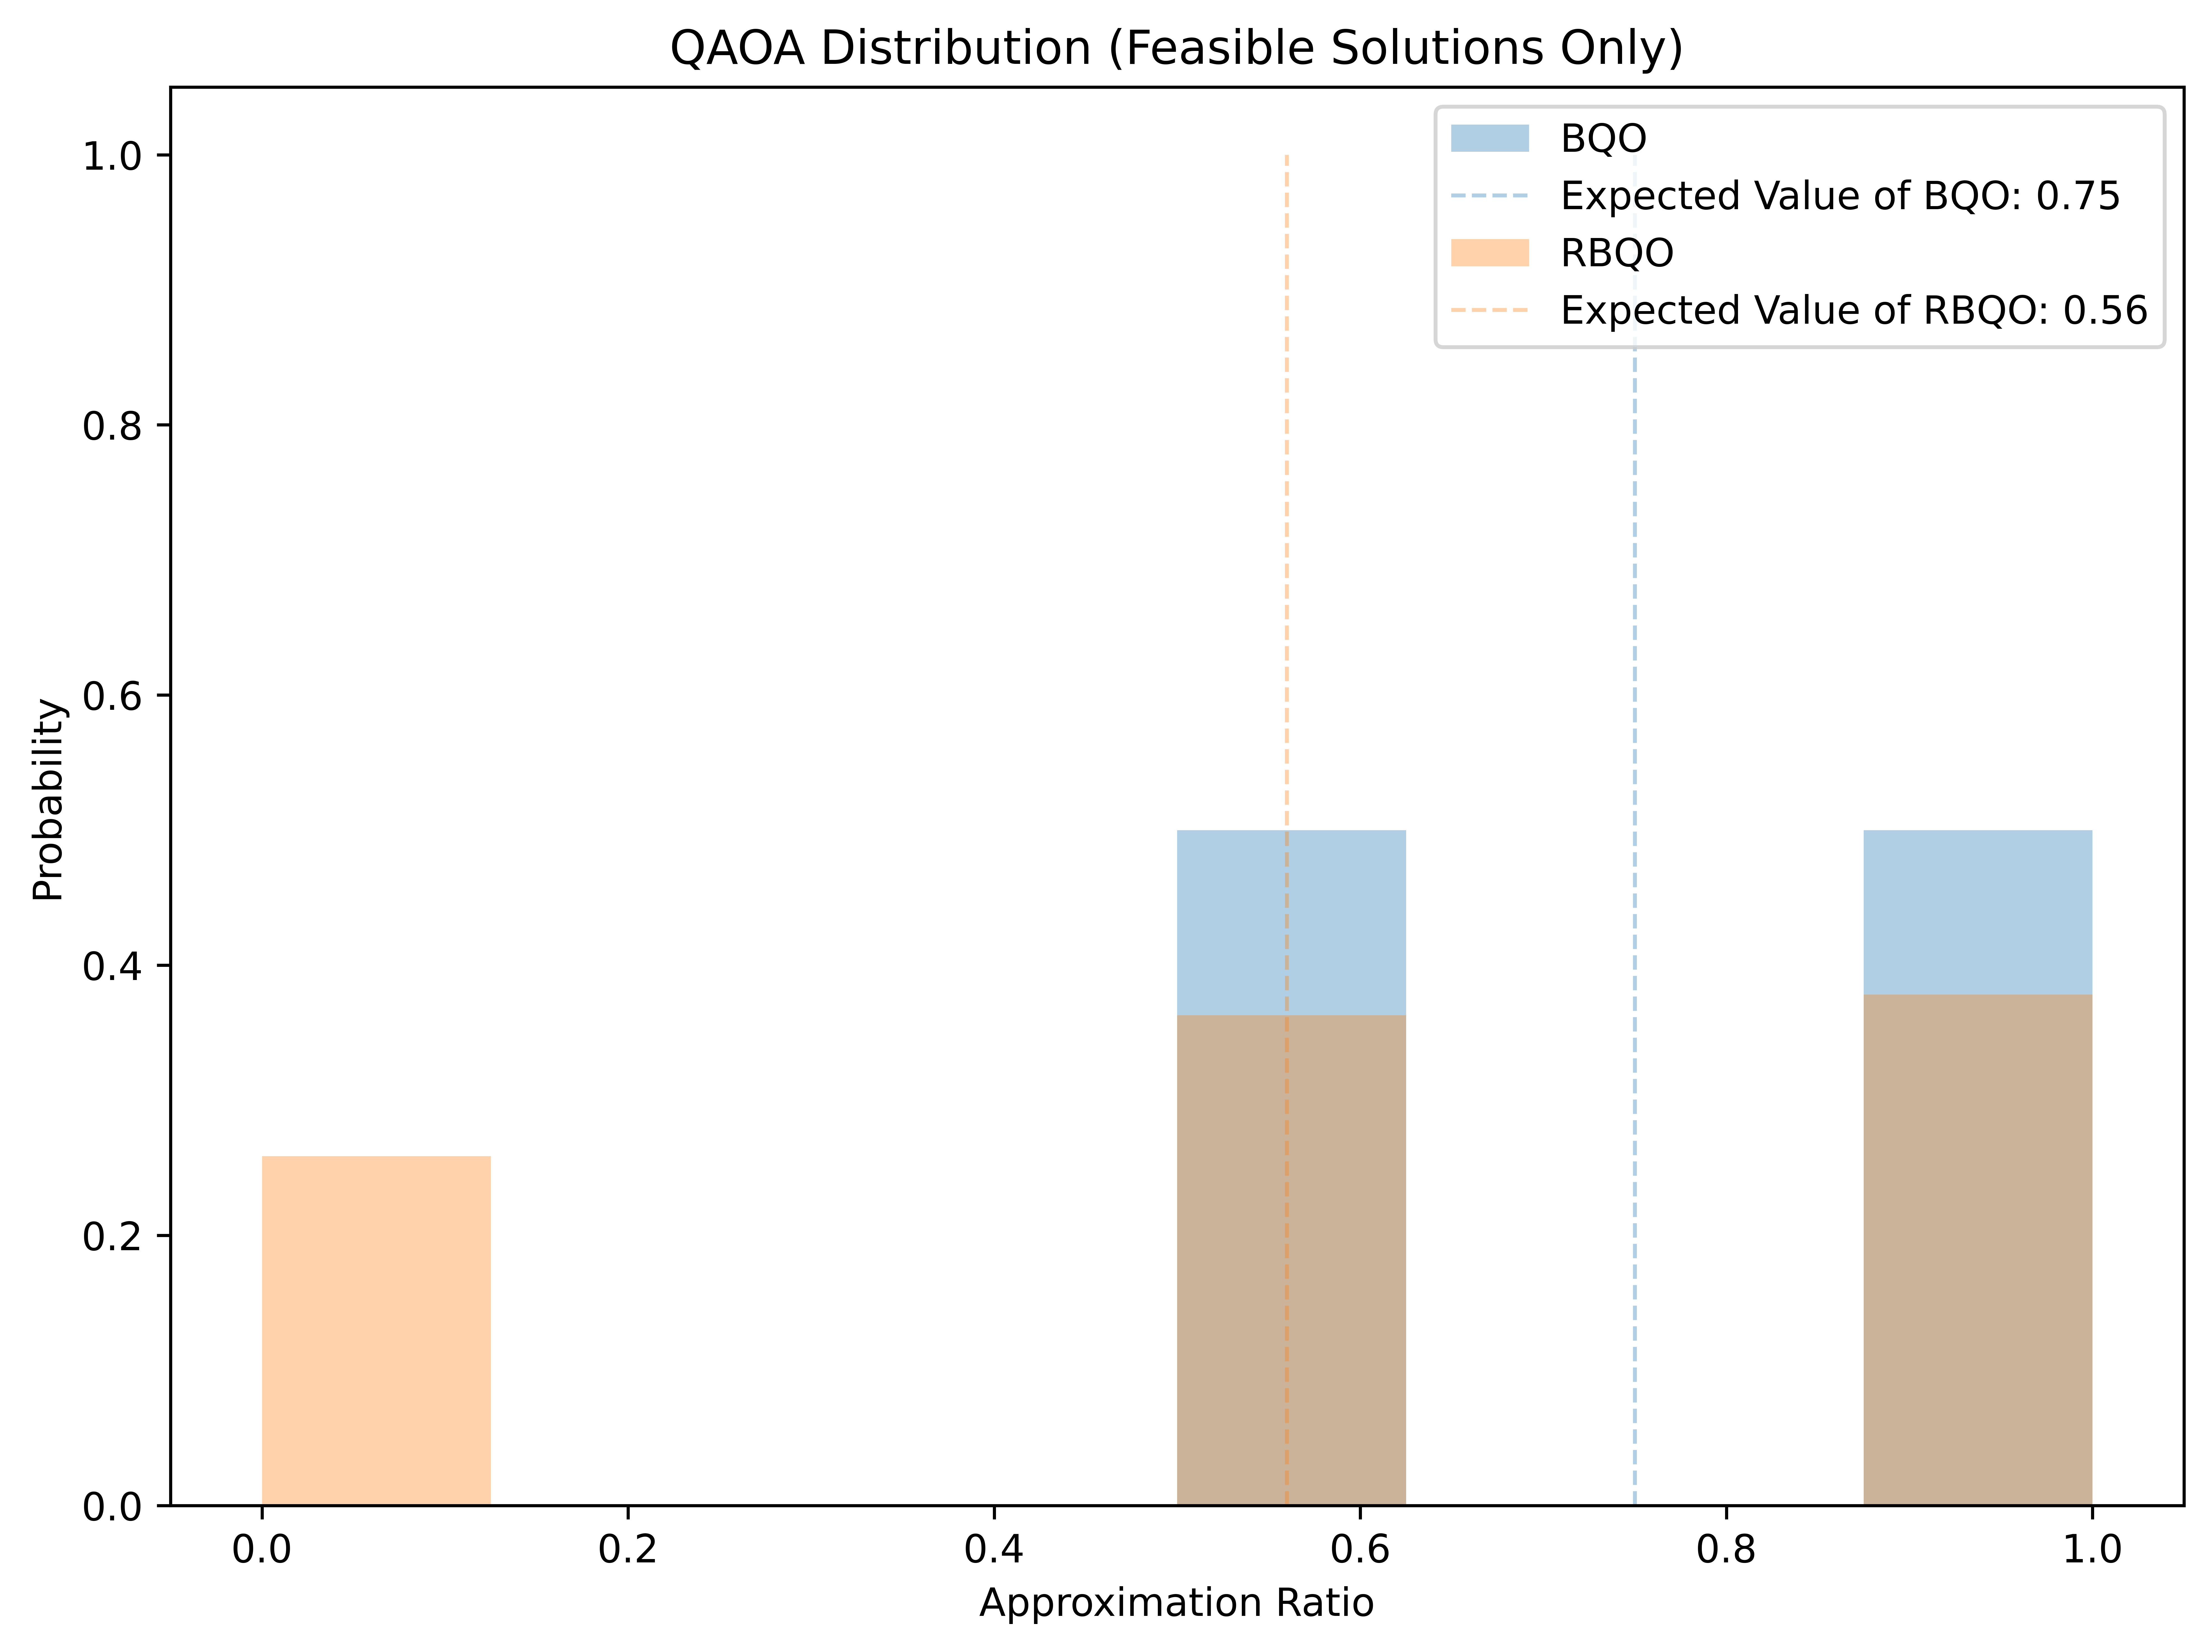

Probability of feasible solution for QUBO (Tight): 0.0215
Probability of feasible solution for QUBO (Naive): 0.1523


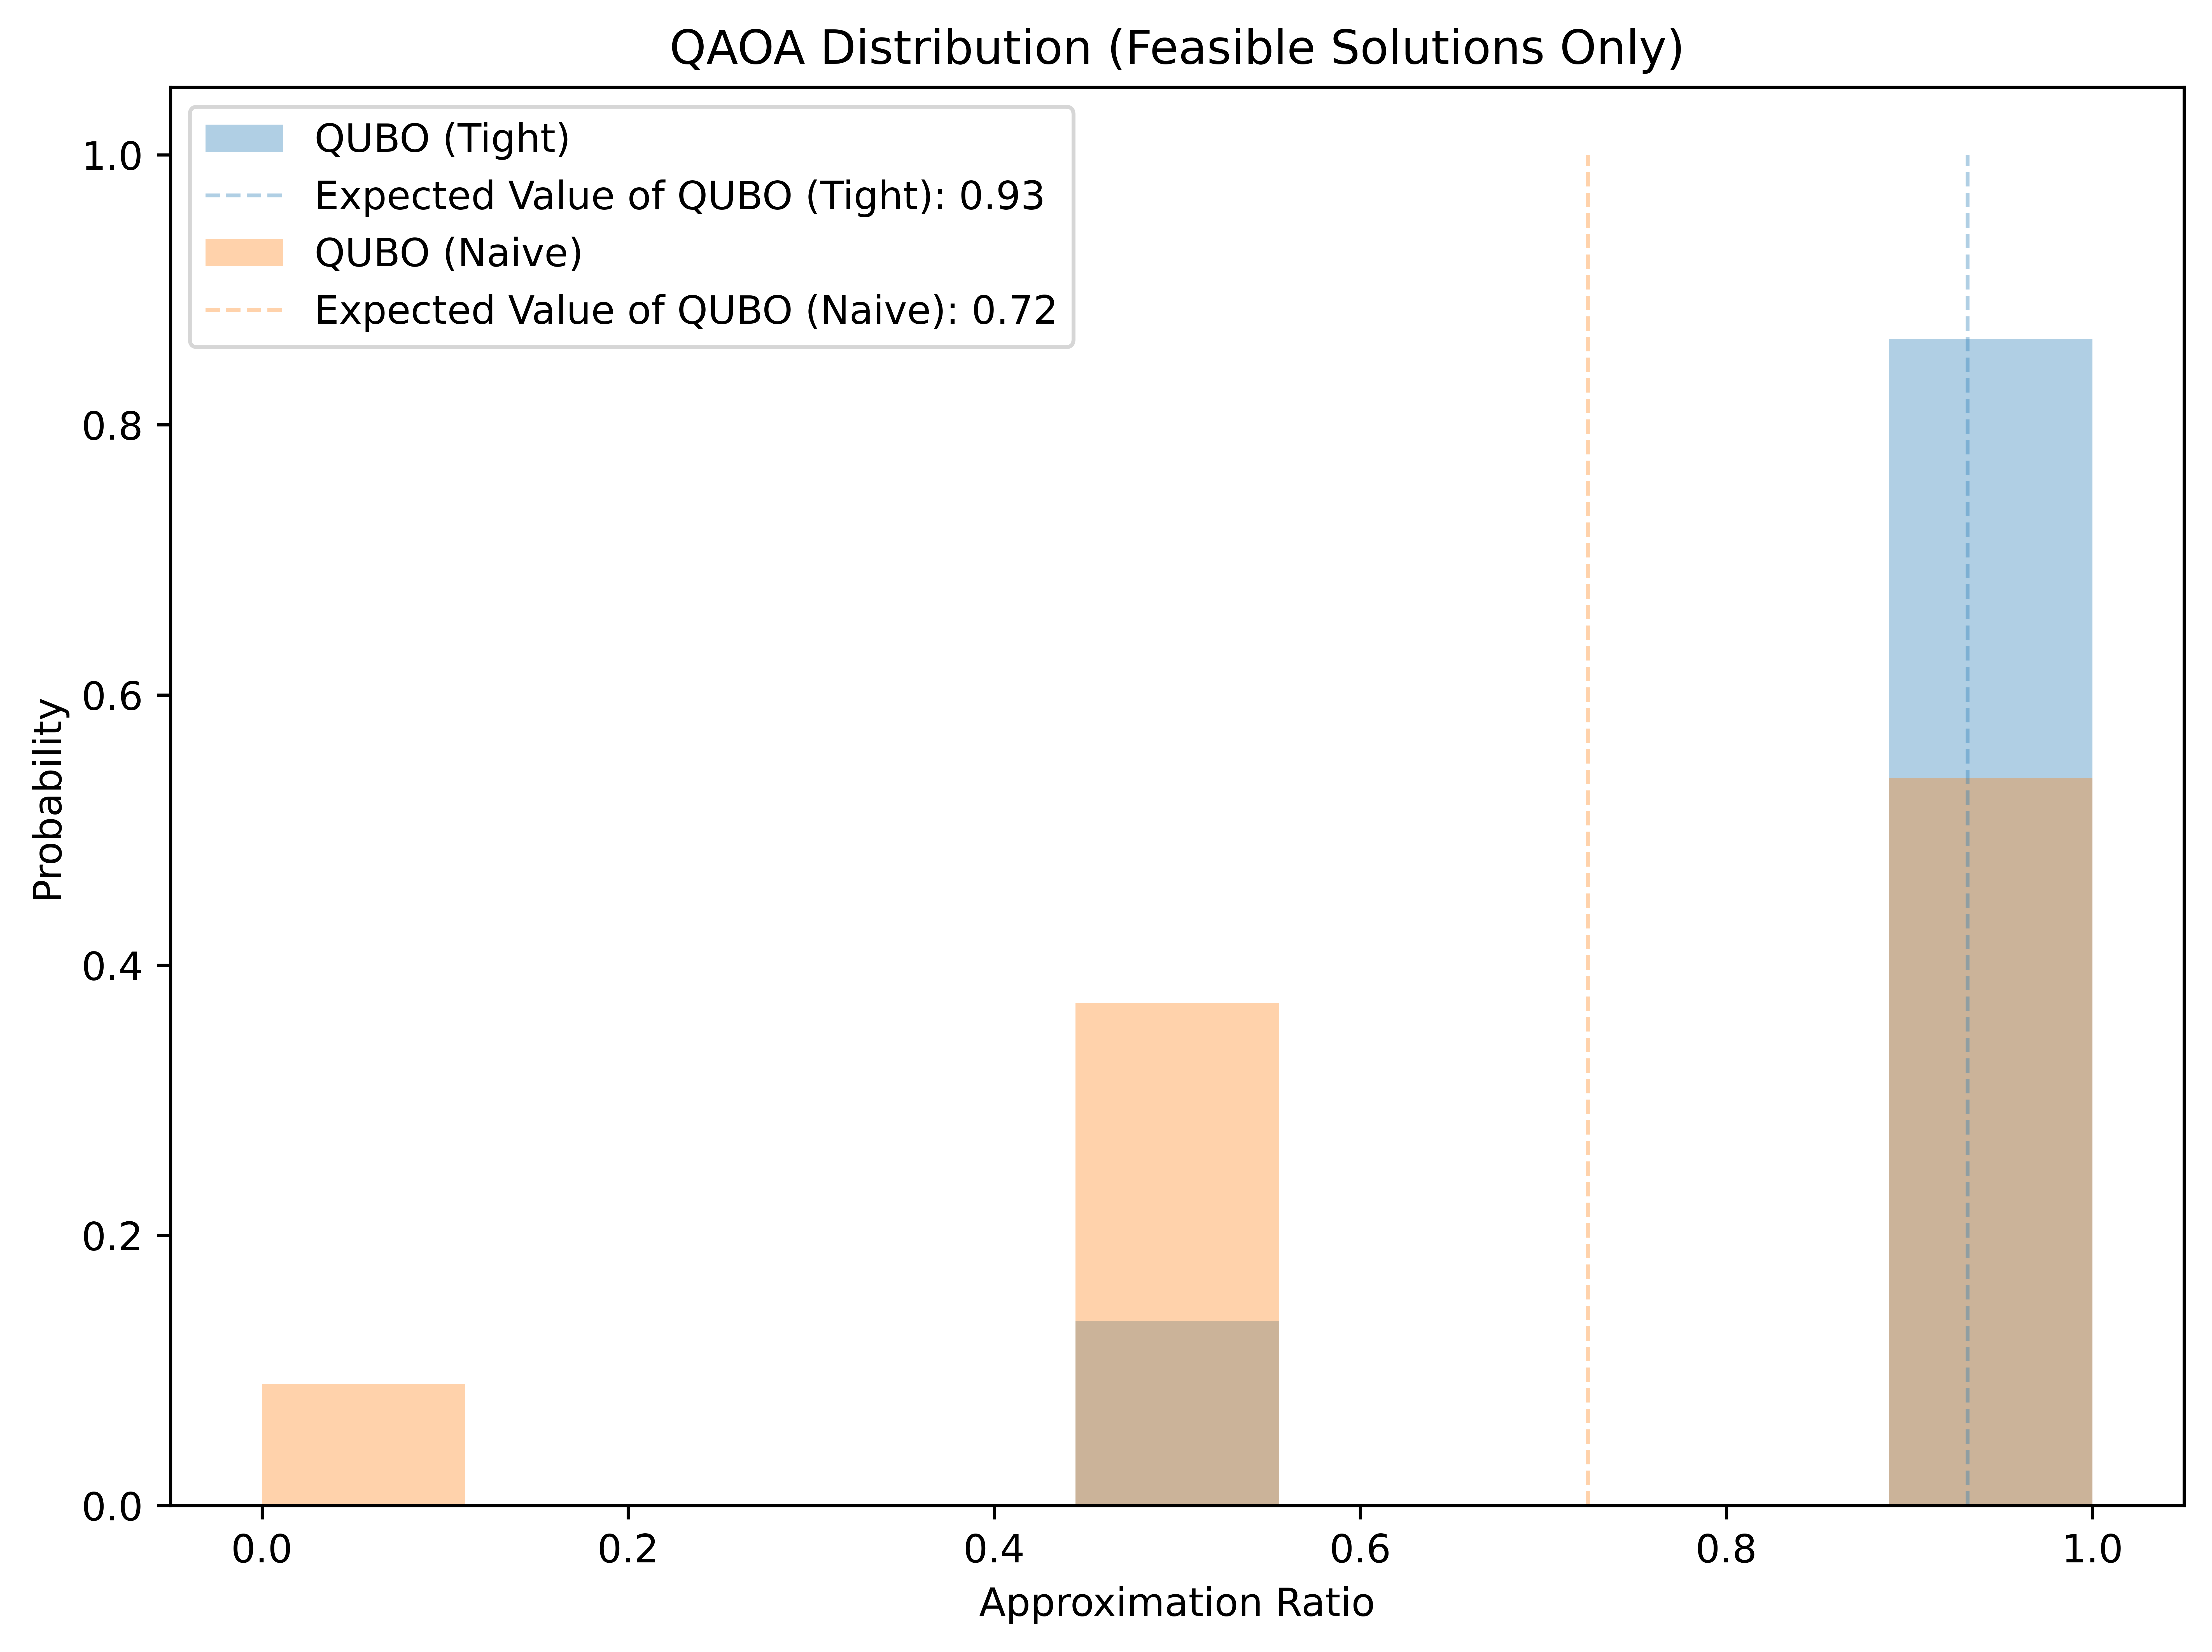

Probability of feasible solution for RQUBO (Tight): 0.2256
Probability of feasible solution for RQUBO (Naive): 0.7998


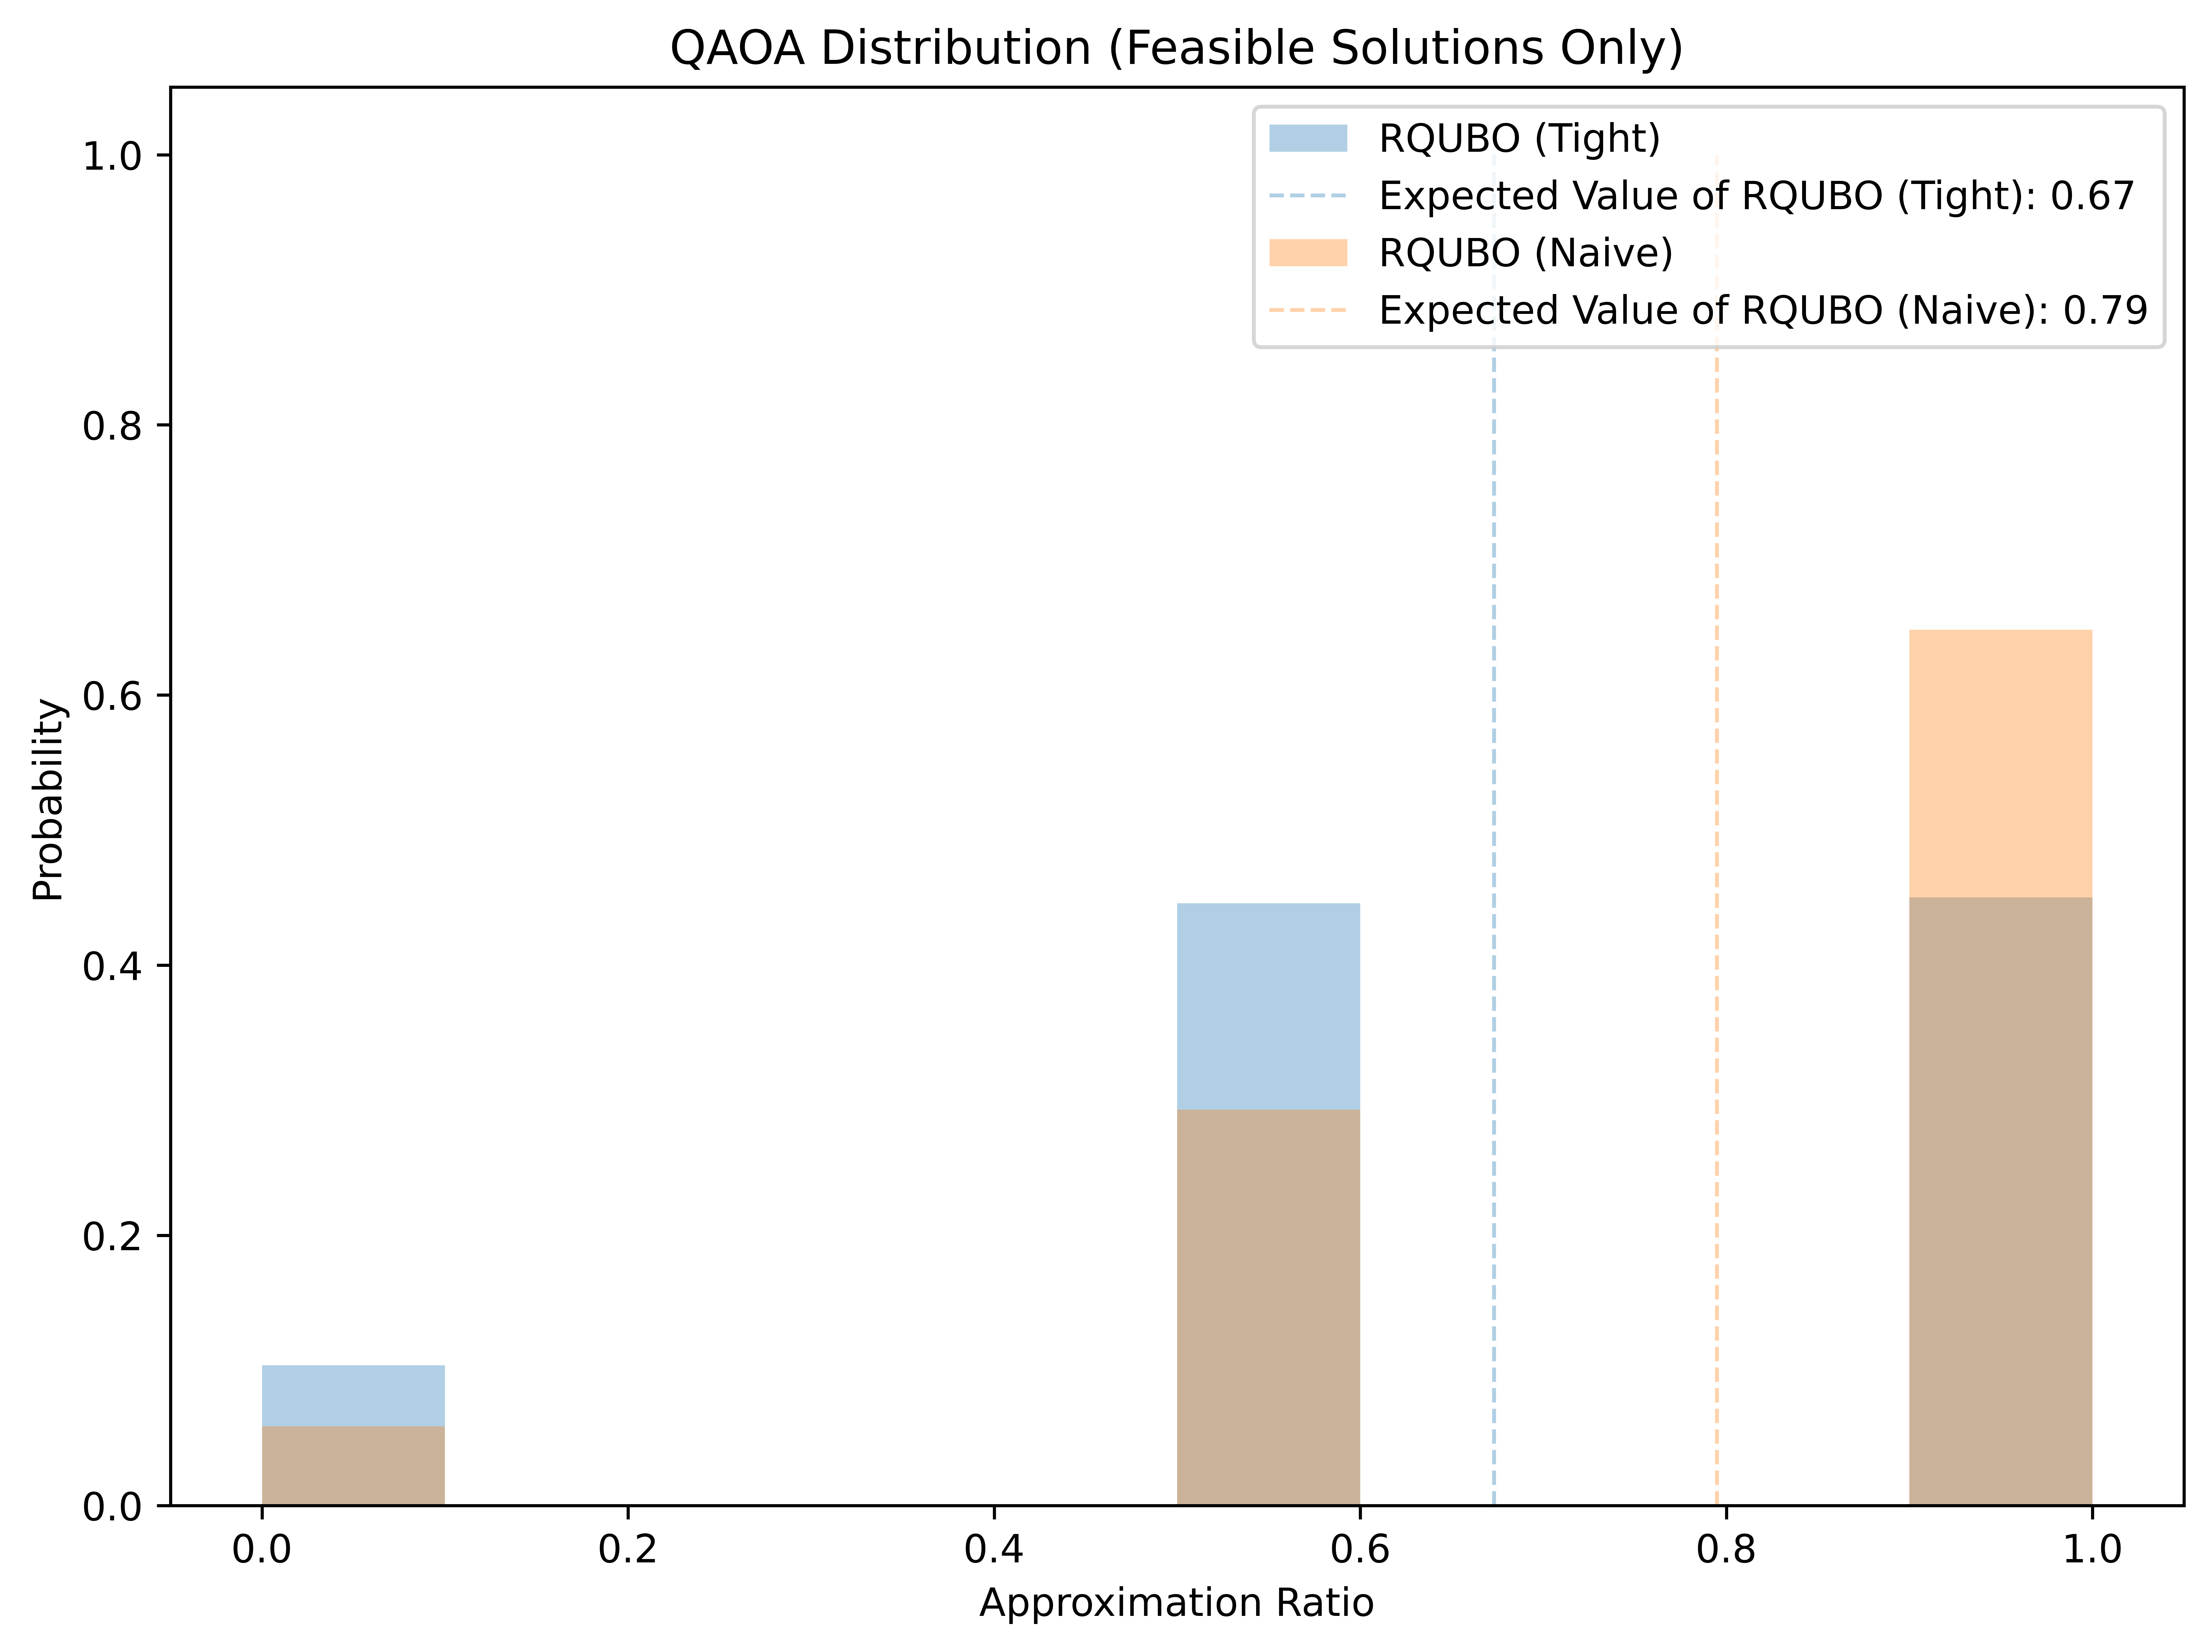

In [10]:
# Plot the histogram while filtering out infeasible solutions and renormalizing probabilities.
plot_qaoa_histogram(results_dict, 'BQO', 'RBQO', Graph=G, Partitions=K, filter_infeasible=True)
plot_qaoa_histogram(results_dict, 'QUBO (Tight)', 'QUBO (Naive)', Graph=G, Partitions=K, filter_infeasible=True)
plot_qaoa_histogram(results_dict, 'RQUBO (Tight)', 'RQUBO (Naive)', Graph=G, Partitions=K, filter_infeasible=True)

In [13]:
t_list = np.linspace(0, 1, 11)
alpha_list = [1]

# We will store our computed data in a dictionary keyed by alpha.
data = {}  # Keys: each alpha; Values: dict with keys "qubo_ratios", "rqubo_ratios", "qubo_ratio_stds", "rqubo_ratio_stds", "qubo_feas_probs", "rqubo_feas_probs"

for alpha in alpha_list:
    print(f"alpha = {alpha}")
    qubo_ratios = []
    rqubo_ratios = []
    qubo_ratio_stds = []
    rqubo_ratio_stds = []
    qubo_feas_probs = []
    rqubo_feas_probs = []
    
    for t in t_list:
        print(f"  t = {t}")
        # Suppress unwanted prints from the simulation code
        with contextlib.redirect_stdout(io.StringIO()):
            # 1) Build and run QAOA
            backend = AerSimulator()
            sampler = Sampler()
            cvar_alpha = alpha
            shots = 1024 / cvar_alpha
            sampler.set_options(shots=shots, backend=backend)
            optimizer = COBYLA()
            reps = 1
            initial_point = np.zeros(2 * reps)

            qaoa = QAOA(
                sampler=sampler,
                optimizer=optimizer,
                reps=reps,
                initial_point=initial_point,
                aggregation=cvar_alpha
            )
            qaoa_optimizer = MinimumEigenOptimizer(qaoa)

            # 2) Build QUBO/RQUBO with interpolated penalties
            dp_qubo_interp = docplex_QUBO(G, K, interpolated_qubo_penalty(G, K, t), "Max-K-Cut")
            dp_rqubo_interp = docplex_RQUBO(G, K, interpolated_rqubo_penalty(G, K, t), "Max-K-Cut")

            # 3) Run QAOA and extract samples
            results_dict_full = run_qaoa_extract_samples(
                [dp_qubo_interp, dp_rqubo_interp],
                ["QUBO (Interpolated)", "RQUBO (Interpolated)"],
                optimizer=qaoa_optimizer
            )

            # 4) Retrieve samples
            full_qubo_samples = results_dict_full["QUBO (Interpolated)"]["samples"]
            full_rqubo_samples = results_dict_full["RQUBO (Interpolated)"]["samples"]

            # 5) Filter feasible samples
            filtered_qubo_samples, qubo_feas_prob = feasibility_filter(G, K, full_qubo_samples, "QUBO (Interpolated)")
            filtered_rqubo_samples, rqubo_feas_prob = feasibility_filter(G, K, full_rqubo_samples, "RQUBO (Interpolated)")

            # 6) Compute expected values
            exp_val_filtered_qubo = expected_value(filtered_qubo_samples)
            exp_val_filtered_rqubo = expected_value(filtered_rqubo_samples)

            # 7) Compute standard deviations
            std_filtered_qubo = sample_std(filtered_qubo_samples, exp_val_filtered_qubo)
            std_filtered_rqubo = sample_std(filtered_rqubo_samples, exp_val_filtered_rqubo)

            # 8) Store data for this t value
            qubo_ratios.append(exp_val_filtered_qubo)
            rqubo_ratios.append(exp_val_filtered_rqubo)
            qubo_ratio_stds.append(std_filtered_qubo)
            rqubo_ratio_stds.append(std_filtered_rqubo)
            
            qubo_feas_probs.append(qubo_feas_prob)
            rqubo_feas_probs.append(rqubo_feas_prob)
    
    # Save all results for the current alpha into the data dictionary.
    data[alpha] = {
       "qubo_ratios": qubo_ratios,
       "rqubo_ratios": rqubo_ratios,
       "qubo_ratio_stds": qubo_ratio_stds,
       "rqubo_ratio_stds": rqubo_ratio_stds,
       "qubo_feas_probs": qubo_feas_probs,
       "rqubo_feas_probs": rqubo_feas_probs
    }

print("Data collection complete.")

alpha = 1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.30000000000000004
  t = 0.4
  t = 0.5
  t = 0.6000000000000001
  t = 0.7000000000000001
  t = 0.8
  t = 0.9
  t = 1.0
Data collection complete.


In [14]:
# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, len(alpha_list), figsize=(18, 10), sharex=True, squeeze=False)

for col_idx, alpha in enumerate(alpha_list):
    # Retrieve stored data for this alpha.
    d = data[alpha]
    qubo_ratios = d["qubo_ratios"]
    rqubo_ratios = d["rqubo_ratios"]
    qubo_ratio_stds = d["qubo_ratio_stds"]
    rqubo_ratio_stds = d["rqubo_ratio_stds"]
    qubo_feas_probs = d["qubo_feas_probs"]
    rqubo_feas_probs = d["rqubo_feas_probs"]
    
    # -----------------------------
    # Plot in the top row: Expected Approximation Ratio
    # -----------------------------
    ax_top = axs[0, col_idx]
    ax_top.plot(t_list, qubo_ratios, label="QUBO", color=qubo_color, linestyle='--')
    ax_top.fill_between(t_list,
                        np.array(qubo_ratios) - np.array(qubo_ratio_stds),
                        np.array(qubo_ratios) + np.array(qubo_ratio_stds),
                        color=qubo_color, alpha=0.15)
    ax_top.plot(t_list, rqubo_ratios, label="RQUBO", color=rqubo_color, linestyle='--')
    ax_top.fill_between(t_list,
                        np.array(rqubo_ratios) - np.array(rqubo_ratio_stds),
                        np.array(rqubo_ratios) + np.array(rqubo_ratio_stds),
                        color=rqubo_color, alpha=0.15)
    ax_top.set_ylim(0, 1)
    ax_top.set_ylabel('Approximation Ratio')
    ax_top.legend()

    # -----------------------------
    # Plot in the bottom row: Feasibility Probability
    # -----------------------------
    ax_bottom = axs[1, col_idx]
    ax_bottom.plot(t_list, qubo_feas_probs, label="QUBO", color=qubo_color, linestyle='--', marker='o')
    ax_bottom.plot(t_list, rqubo_feas_probs, label="RQUBO", color=rqubo_color, linestyle='--', marker='o')
    ax_bottom.set_ylim(0, 1.05)
    ax_bottom.set_xlabel('t')
    ax_bottom.set_ylabel('Feasibility Probability')
    ax_bottom.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Experiment parameters
num_graphs = 30
K = 3
num_nodes = 7
edge_probability = 0.5
weighted = False
weight_range = 1


# Interpolation parameter: t=0 corresponds to one endpoint (naive) and t=1 to the other (tight)
t_list = np.linspace(0, 1, 6)  # adjust the number of t values as needed


# For each t value, compute the mean and standard deviation across graphs.
mean_qubo_exp_val = np.zeros(len(t_list))
std_qubo_exp_val= np.zeros(len(t_list))

mean_qubo_feas_prob = np.zeros(len(t_list))  
std_qubo_feas_prob = np.zeros(len(t_list))

mean_rqubo_exp_val = np.zeros(len(t_list))
std_rqubo_exp_val = np.zeros(len(t_list))

mean_rqubo_feas_prob = np.zeros(len(t_list))
std_rqubo_feas_prob = np.zeros(len(t_list))

# Interpolation parameter: t=0 corresponds to one endpoint (naive) and t=1 to the other (tight)
t_list = np.linspace(0, 1, 6)  # adjust the number of t values as needed

# We'll record the feasibility probability (as a fraction between 0 and 1) for each model at each t.
# For convenience, we use dictionaries keyed by t.
model_mean_qubo_interp = {t: [] for t in t_list}
model_mean_rqubo_interp = {t: [] for t in t_list}
feas_probs_qubo_interp = {t: [] for t in t_list}
feas_probs_rqubo_interp = {t: [] for t in t_list}

: 

In [ ]:
# Loop over graph instances
for i in range(num_graphs):
    print(f"Graph {i + 1}:")
    
    # 1) Generate a random graph
    G = generate_graph(num_nodes, edge_probability, weighted, weight_range)
    
    # For each interpolation parameter t, build interpolated models and record feasibility
    for t in t_list:
        print(f"  t = {t}")
        with contextlib.redirect_stdout(io.StringIO()):
            # Build interpolated models:
            dp_qubo_interp = docplex_QUBO(G, K, interpolated_qubo_penalty(G, K, t), "Max-K-Cut")
            dp_rqubo_interp = docplex_RQUBO(G, K, interpolated_rqubo_penalty(G, K, t), "Max-K-Cut")
            
            # Run QAOA to extract samples
            results_dict = run_qaoa_extract_samples(
                [dp_qubo_interp, dp_rqubo_interp],
                ["QUBO (Interpolated)", "RQUBO (Interpolated)"],
                optimizer=qaoa_optimizer
            )
            
            # Retrieve the raw samples
            samples_qubo = results_dict["QUBO (Interpolated)"]["samples"]
            samples_rqubo = results_dict["RQUBO (Interpolated)"]["samples"]
            
            # Filter the samples and get the feasibility probability.
            # (Assume feasibility_filter returns (filtered_samples, probability_feasible)
            # where probability_feasible is given as a percentage.)
            filtered_samples_qubo, feas_prob_qubo = feasibility_filter(G, K, samples_qubo, "QUBO (Interpolated)")
            filtered_samples_rqubo, feas_prob_rqubo = feasibility_filter(G, K, samples_rqubo, "RQUBO (Interpolated)")
        
        model_mean_qubo_interp[t].append(expected_value(filtered_samples_qubo))
        model_mean_rqubo_interp[t].append(expected_value(filtered_samples_rqubo))
        feas_probs_qubo_interp[t].append(feas_prob_qubo)
        feas_probs_rqubo_interp[t].append(feas_prob_rqubo)

    for index, t in enumerate(t_list):
        #now make a new plot for each additional graph
        qubo_exp_vals = np.array(model_mean_qubo_interp[t])
        mean_qubo_exp_val[index] = np.mean(qubo_exp_vals)
        std_qubo_exp_val[index] = np.std(qubo_exp_vals)

        qubo_probs = np.array(feas_probs_qubo_interp[t])
        mean_qubo_feas_prob[index] = np.mean(qubo_probs)
        std_qubo_feas_prob[index] = np.std(qubo_probs)

        rqubo_exp_vals = np.array(model_mean_rqubo_interp[t])
        mean_rqubo_exp_val[index] = np.mean(rqubo_exp_vals)
        std_rqubo_exp_val[index] = np.std(rqubo_exp_vals)

        rqubo_probs = np.array(feas_probs_rqubo_interp[t])
        mean_rqubo_feas_prob[index] = np.mean(rqubo_probs)
        std_rqubo_feas_prob[index] = np.std(rqubo_probs)

    # Custom colors:
    qubo_color = "cornflowerblue"
    rqubo_color = "orange"

    # Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
    # By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
    fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    # -----------------------------
    # Plot in the top row: Expected Approximation Ratio
    # -----------------------------
    ax_top = axs[0]
    ax_top.plot(t_list, mean_qubo_exp_val, label="QUBO", color=qubo_color, linestyle='-')
    ax_top.fill_between(t_list,
                        np.array(mean_qubo_exp_val) - np.array(std_qubo_exp_val),
                        np.array(mean_qubo_exp_val) + np.array(std_qubo_exp_val),
                        color=qubo_color, alpha=0.15)

    ax_top.plot(t_list, mean_rqubo_exp_val, label="RQUBO", color=rqubo_color, linestyle='-')
    ax_top.fill_between(t_list,
                        np.array(mean_rqubo_exp_val) - np.array(std_rqubo_exp_val),
                        np.array(mean_rqubo_exp_val) + np.array(std_rqubo_exp_val),
                        color=rqubo_color, alpha=0.15)

    ax_top.set_ylim(0, 1)
    ax_top.set_ylabel('Approximation Ratio')
    ax_top.legend()

    # -----------------------------
    # Plot in the bottom row: Feasibility Probability
    # -----------------------------
    ax_bottom = axs[1]
    ax_bottom.plot(t_list, mean_qubo_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
    ax_bottom.fill_between(t_list,
                        np.array(mean_qubo_feas_prob) - np.array(std_qubo_feas_prob),
                        np.array(mean_qubo_feas_prob) + np.array(std_qubo_feas_prob),
                        color=qubo_color, alpha=0.15)

    ax_bottom.plot(t_list, mean_rqubo_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
    ax_bottom.fill_between(t_list,
                        np.array(mean_rqubo_feas_prob) - np.array(std_rqubo_feas_prob),
                        np.array(mean_rqubo_feas_prob) + np.array(std_rqubo_feas_prob),
                        color=rqubo_color, alpha=0.15)

    ax_bottom.set_ylim(0, 1)
    ax_bottom.set_xlabel('t')
    ax_bottom.set_ylabel('Feasibility Probability')
    ax_bottom.legend()

    plt.tight_layout()
    os.makedirs("Plots", exist_ok=True)
    plt.savefig("Plots/interpolated_penalties.png")
    
print("Data collection complete.")

Graph 1:
  t = 0.0


capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.
Fatal Python error: F2PySwapThreadLocalCallbackPtr: F2PySwapThreadLocalCallbackPtr: PyLong_AsVoidPtr failed
Python runtime state: initialized
Traceback (most recent call last):
  File "/Users/hark469/Projects/max-k-cut/Max_K_Cut/.venv/lib/python3.12/site-packages/scipy/optimize/_cobyla_py.py", line 281, in calcfc
    f = sf.fun(x)
        ^^^^^^^^^
  File "/Users/hark469/Projects/max-k-cut/Max_K_Cut/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py", line 325, in fun
    self._update_fun()
  File "/Users/hark469/Projects/max-k-cut/Max_K_Cut/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py", line 294, in _update_fun
    fx = self._wrapped_fun(self.x)
         ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hark469/Projects/max-k-cut/Max_K_Cut/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py", line 20, in wrapped
    fx = fun(np.copy

In [ ]:
# for t in t_list:
#     qubo_exp_vals = np.array(model_mean_qubo_interp[t])
#     mean_qubo_exp_val.append(np.mean(qubo_exp_vals))
#     std_qubo_exp_val.append(np.std(qubo_exp_vals))

#     qubo_probs = np.array(feas_probs_qubo_interp[t])
#     mean_qubo_feas_prob.append(np.mean(qubo_probs))
#     std_qubo_feas_prob.append(np.std(qubo_probs))

#     rqubo_exp_vals = np.array(model_mean_rqubo_interp[t])
#     mean_rqubo_exp_val.append(np.mean(rqubo_exp_vals))
#     std_rqubo_exp_val.append(np.std(rqubo_exp_vals))

#     rqubo_probs = np.array(feas_probs_rqubo_interp[t])
#     mean_rqubo_feas_prob.append(np.mean(rqubo_probs))
#     std_rqubo_feas_prob.append(np.std(rqubo_probs))

# # Custom colors:
# qubo_color = "cornflowerblue"
# rqubo_color = "orange"

# # Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# # By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
# fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
# # -----------------------------
# # Plot in the top row: Expected Approximation Ratio
# # -----------------------------
# ax_top = axs[0]
# ax_top.plot(t_list, mean_qubo_exp_val, label="QUBO", color=qubo_color, linestyle='-')
# ax_top.fill_between(t_list,
#                     np.array(mean_qubo_exp_val) - np.array(std_qubo_exp_val),
#                     np.array(mean_qubo_exp_val) + np.array(std_qubo_exp_val),
#                     color=qubo_color, alpha=0.15)

# ax_top.plot(t_list, mean_rqubo_exp_val, label="RQUBO", color=rqubo_color, linestyle='-')
# ax_top.fill_between(t_list,
#                     np.array(mean_rqubo_exp_val) - np.array(std_rqubo_exp_val),
#                     np.array(mean_rqubo_exp_val) + np.array(std_rqubo_exp_val),
#                     color=rqubo_color, alpha=0.15)

# ax_top.set_ylim(0, 1)
# ax_top.set_ylabel('Approximation Ratio')
# ax_top.legend()

# # -----------------------------
# # Plot in the bottom row: Feasibility Probability
# # -----------------------------
# ax_bottom = axs[1]
# ax_bottom.plot(t_list, mean_qubo_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
# ax_bottom.fill_between(t_list,
#                       np.array(mean_qubo_feas_prob) - np.array(std_qubo_feas_prob),
#                       np.array(mean_qubo_feas_prob) + np.array(std_qubo_feas_prob),
#                       color=qubo_color, alpha=0.15)

# ax_bottom.plot(t_list, mean_rqubo_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
# ax_bottom.fill_between(t_list,
#                       np.array(mean_rqubo_feas_prob) - np.array(std_rqubo_feas_prob),
#                       np.array(mean_rqubo_feas_prob) + np.array(std_rqubo_feas_prob),
#                       color=rqubo_color, alpha=0.15)

# ax_bottom.set_ylim(0, 1)
# ax_bottom.set_xlabel('t')
# ax_bottom.set_ylabel('Feasibility Probability')
# ax_bottom.legend()

# plt.tight_layout()
# os.makedirs("Plots", exist_ok=True)
# plt.savefig("Plots/interpolated_penalties.png")